# Cleaning Round_stat dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
rdata = pd.read_csv("/content/afl_plyer_rbr_st_raw.csv")
rdata

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994.0,17.0,Richmond Tigers,21,W,34.0,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552.0,1994-08-14,36.0,NaN,28.0
1,614897,Geelong Cats,2024.0,1.0,St Kilda Saints,1,W,7.0,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356.0,2024-03-16,23.0,NaN,8.0
2,583553,Essendon Bombers,1999.0,97.0,Adelaide Crows,10,W,6.0,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955.0,1999-06-04,67.0,NaN,48.0
3,590676,Western Bulldogs,1994.0,36.0,St Kilda Saints,21,W,35.0,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656.0,1994-08-13,81.0,NaN,45.0
4,582473,Richmond Tigers,1997.0,113.0,Melbourne Demons,10,L,41.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929.0,1997-05-31,32.0,NaN,-25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14113,540041,Adelaide Crows,2003.0,40.0,Hawthorn Hawks,11,L,28.0,9.0,2.0,...,1.0,2.0,NaN,NaN,94.0,45344.0,2003-06-07,63.0,NaN,-5.0
14114,94578,Adelaide Crows,2004.0,1.0,Richmond Tigers,5,W,44.0,3.0,2.0,...,2.0,0.0,0.0,0.0,56.0,43407.0,2004-04-23,28.0,NaN,75.0
14115,540052,Adelaide Crows,2004.0,51.0,Richmond Tigers,5,W,28.0,4.0,2.0,...,NaN,2.0,NaN,NaN,89.0,45344.0,2004-04-23,32.0,NaN,75.0
14116,516971,Adelaide Crows,2004.0,90.0,Richmond Tigers,5,W,24.0,11.0,6.0,...,1.0,1.0,1.0,1.0,98.0,45396.0,2004-04-23,78.0,NaN,75.0


In [3]:
print("Raw data information",rdata.shape)
print(rdata.info())
print(rdata.describe(include="all"),"\n")

Raw data information (14118, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14118 entries, 0 to 14117
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         14118 non-null  int64  
 1   team                       14118 non-null  object 
 2   year                       14117 non-null  float64
 3   career_game_count          14117 non-null  float64
 4   opponent                   14117 non-null  object 
 5   round                      14117 non-null  object 
 6   result                     14117 non-null  object 
 7   jersey_num                 14117 non-null  float64
 8   kicks                      14066 non-null  float64
 9   marks                      13765 non-null  float64
 10  handballs                  13902 non-null  float64
 11  disposals                  13881 non-null  float64
 12  goals                      10258 non-null  float64
 13  behinds      

In [4]:
print("Round_stats missing values before cleaning:\n",rdata.isnull().sum())

Round_stats missing values before cleaning:
 id                               0
team                             0
year                             1
career_game_count                1
opponent                         1
round                            1
result                           1
jersey_num                       1
kicks                           52
marks                          353
handballs                      216
disposals                      237
goals                         3860
behinds                       4128
hit_outs                      4769
tackles                       1495
rebound_50s                   2929
inside_50s                    2381
clearances                    3260
clangers                      2415
free_kicks_for                2588
free_kicks_against            2639
brownlow_votes                5529
contested_possessions         1817
uncontested_possessions       1790
contested_marks               4302
marks_inside_50               4519
one_percen

In [5]:
rdata = rdata.drop(columns=["score"])

In [6]:
numeric_columns = rdata.select_dtypes(include="number").columns

for col in numeric_columns:
    if rdata[col].isnull().sum() > 0:
        rdata[col] = rdata[col].fillna(rdata[col].median())

In [7]:
categorical_columns = rdata.select_dtypes(include="object").columns
for col in categorical_columns:
    if rdata[col].isnull().sum() > 0:
        rdata[col] = rdata[col].fillna(rdata[col].mode()[0])

In [8]:
print("Round_stat missing values after cleaning:\n",rdata.isnull().sum())

Round_stat missing values after cleaning:
 id                           0
team                         0
year                         0
career_game_count            0
opponent                     0
round                        0
result                       0
jersey_num                   0
kicks                        0
marks                        0
handballs                    0
disposals                    0
goals                        0
behinds                      0
hit_outs                     0
tackles                      0
rebound_50s                  0
inside_50s                   0
clearances                   0
clangers                     0
free_kicks_for               0
free_kicks_against           0
brownlow_votes               0
contested_possessions        0
uncontested_possessions      0
contested_marks              0
marks_inside_50              0
one_percenters               0
bounces                      0
goal_assist                  0
percentage_of_game_played  

In [9]:
print("Duplicate round_data:", rdata.duplicated().sum())

Duplicate round_data: 0


In [10]:
rdata = rdata.drop_duplicates()

In [11]:
rdata.to_csv("/content/cleaned_round_stats.csv",index=False)
print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


# Task Implementation

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
merged_players = pd.read_csv('/content/merged_players.csv')
round_data=pd.read_csv('/content/cleaned_round_stats.csv')

In [14]:
print("Merged_Players Shape:", merged_players.shape)
print("Round_Stats Shape:", round_data.shape)

Merged_Players Shape: (16027, 68)
Round_Stats Shape: (14118, 35)


In [15]:
print("\nMissing Values:")
print(merged_players.isnull().sum())
print("\nDuplicate Rows:")
print(merged_players.duplicated().sum())


Missing Values:
player_id                0
player_name              0
player_full_name         0
first_name               0
last_name                0
                        ..
avg_bounces              0
avg_goal_assists         0
avg_score                0
avg_fantasy_points       0
avg_percentage_played    0
Length: 68, dtype: int64

Duplicate Rows:
0


In [16]:
print("\nMissing Values:")
print(round_data.isnull().sum())
print("\nDuplicate Rows:")
print(round_data.duplicated().sum())


Missing Values:
id                           0
team                         0
year                         0
career_game_count            0
opponent                     0
round                        0
result                       0
jersey_num                   0
kicks                        0
marks                        0
handballs                    0
disposals                    0
goals                        0
behinds                      0
hit_outs                     0
tackles                      0
rebound_50s                  0
inside_50s                   0
clearances                   0
clangers                     0
free_kicks_for               0
free_kicks_against           0
brownlow_votes               0
contested_possessions        0
uncontested_possessions      0
contested_marks              0
marks_inside_50              0
one_percenters               0
bounces                      0
goal_assist                  0
percentage_of_game_played    0
player_id             

In [17]:
print("Columns in Merged Players:")
print(merged_players.columns.tolist())

Columns in Merged Players:
['player_id', 'player_name', 'player_full_name', 'first_name', 'last_name', 'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age', 'height', 'weight', 'player_link', 'player_common_names', 'player_teams', 'year', 'team', 'is_finals', 'games_played', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assists', 'total_score', 'total_fantasy_points', 'total_percentage_played', 'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_goals', 'avg_behinds', 'avg_hit_outs', 'avg_tackles', 'avg_rebound_50s', 'avg_inside_50s', 'avg_clearances', 'avg_clangers', 'avg_free_kicks_for', 'avg_free_kicks_against', 'avg_contested_possessions', 'avg_uncontested_possessions', 'avg_contested

In [18]:
print("\nRound_Stat Columns:")
print(round_data.columns.tolist())


Round_Stat Columns:
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'margin']


In [19]:
int_columns = ['player_id','year','kicks','marks','handballs','disposals','goals','behinds',
               'hit_outs','tackles','rebound_50s','inside_50s','clearances','clangers','free_kicks_for',
               'free_kicks_against','brownlow_votes','contested_possessions','uncontested_possessions',
               'contested_marks','marks_inside_50','one_percenters','bounces','total_score','total_fantasy_points']
# Convert integer columns
for col in int_columns:
    merged_players[col] = merged_players[col].fillna(0).astype('int64')

# Date columns
date_columns = ['born_date','debut_date','last_date']
for col in date_columns:
    merged_players[col] = pd.to_datetime(merged_players[col])

In [20]:
print("MERGED PLAYERS INFO")
merged_players.info()

print("\nROUND STATS INFO")
round_data.info()

MERGED PLAYERS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16027 entries, 0 to 16026
Data columns (total 68 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    16027 non-null  int64         
 1   player_name                  16027 non-null  object        
 2   player_full_name             16027 non-null  object        
 3   first_name                   16027 non-null  object        
 4   last_name                    16027 non-null  object        
 5   born_date                    16027 non-null  datetime64[ns]
 6   debut_date                   16027 non-null  datetime64[ns]
 7   debut_age                    16027 non-null  int64         
 8   last_date                    16027 non-null  datetime64[ns]
 9   last_age                     16027 non-null  int64         
 10  height                       16027 non-null  int64         
 11  weight               

## **2020 to 2025 Data**

In [21]:
players = merged_players[(merged_players["year"] >= 2020) &(merged_players["year"] <= 2025) &(merged_players["is_finals"] == False)].copy()

r_stat = round_data[(round_data["year"] >= 2020) &(round_data["year"] <= 2025) &(~round_data["round"].isin(["SF", "QF", "PF", "EF", "GF"]))].copy()

print(players.shape)
print(r_stat.shape)

(2910, 68)
(2851, 35)


In [22]:
players = (players.groupby(["player_id", "player_name"])
    .agg(games_played=("games_played", "sum"),goals=("goals", "sum"),disposals=("disposals", "sum"),tackles=("tackles", "sum"),clearances=("clearances", "sum"),total_fantasy_points=("total_fantasy_points", "sum"),contested_possessions=("contested_possessions", "sum"),)
    .reset_index())

# **Feature Engineering**

In [23]:
# Goals per Game
players['Goals_per_Game'] = (players['goals'] / players['games_played']).fillna(0)

# Disposals per Game
players['Disposals_per_Game'] = (players['disposals'] / players['games_played']).fillna(0)

# Tackles per Game
players['Tackles_per_Game'] = (players['tackles'] / players['games_played']).fillna(0)

# Clearance per Game
players['Clearances_per_Game'] = (players['clearances'] / players['games_played']).fillna(0)

# Fantasy points per Game
players['Fantasy_per_Game'] = (players['total_fantasy_points'] / players['games_played']).fillna(0)

# Contested Possessions per Game
players['Contested_Per_Game'] = (players['contested_possessions'] / players['games_played']).fillna(0)

# Display New Features
players[["player_name","Goals_per_Game","Disposals_per_Game","Tackles_per_Game","Clearances_per_Game","Fantasy_per_Game","Contested_Per_Game"]].head()

,player_name,Goals_per_Game,Disposals_per_Game,Tackles_per_Game,Clearances_per_Game,Fantasy_per_Game,Contested_Per_Game
0,Ryan Abbott,1.000000,3.000000,0.000000,0.000000,22.000000,0.000000
1,Gary Ablett,0.875000,16.625000,2.375000,1.375000,61.375000,7.750000
2,Blake Acres,0.301887,20.754717,2.716981,1.707547,80.396226,6.509434
3,Marcus Adams,0.029412,13.411765,1.441176,0.176471,57.529412,5.558824
4,Taylor Adams,0.376344,20.720430,4.645161,4.505376,80.215054,9.537634


# **Top 10 Players using Performance index**

In [24]:
players["Performance_Index"] = (players["Fantasy_per_Game"].rank(pct=True)
    + players["Disposals_per_Game"].rank(pct=True)
    + players["Goals_per_Game"].rank(pct=True)
    + players["Tackles_per_Game"].rank(pct=True)
    + players["Clearances_per_Game"].rank(pct=True)
    + players["Contested_Per_Game"].rank(pct=True)) / 6 * 100

In [25]:
top_10_players = players.sort_values("Performance_Index", ascending=False).head(10)
top_10_players[[
    "player_name",
    "player_id",
    "games_played",
    "Performance_Index",
    "Fantasy_per_Game",
    "Disposals_per_Game",
    "Goals_per_Game",
    "Tackles_per_Game",
    "Clearances_per_Game"]].round(2)

,player_name,player_id,games_played,Performance_Index,Fantasy_per_Game,Disposals_per_Game,Goals_per_Game,Tackles_per_Game,Clearances_per_Game
512,Christian Petracca,44681,120,94.54,98.73,26.52,0.98,3.60,4.99
141,Patrick Cripps,43642,125,94.03,90.02,25.16,0.61,5.14,6.80
646,Tim Taranto,45061,108,93.45,99.17,25.80,0.58,5.33,4.96
499,Luke Parker,44651,112,92.71,90.38,23.82,0.56,4.67,5.47
483,Lachie Neale,44585,119,92.20,98.99,28.05,0.45,3.84,6.89
457,Touk Miller,44497,112,91.95,99.88,26.38,0.38,5.47,5.46
282,Isaac Heeney,44025,114,91.73,88.59,19.21,1.58,3.82,3.17
628,Jack Steele,45003,121,91.32,104.56,24.48,0.36,7.51,5.17
372,Tom Liberatore,44281,119,91.24,91.50,24.76,0.36,5.34,7.05
688,Chad Warner,45179,100,91.15,86.83,22.26,0.92,3.77,3.94


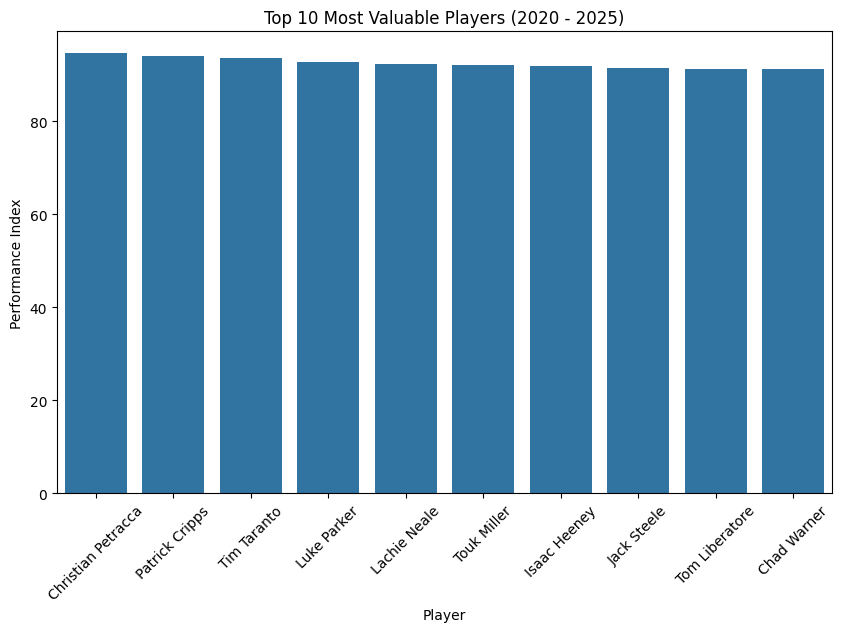

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_10_players,x="player_name",y="Performance_Index")
plt.title("Top 10 Most Valuable Players (2020 - 2025)")
plt.xlabel("Player")
plt.ylabel("Performance Index")
plt.xticks(rotation=45)
plt.show()

# **Finding Consistet Players**

In [27]:
# Player-wise Fantasy Point consistency
consistency = r_stat.groupby('player_id').agg(
    Games=('fantasy_points', 'count'),
    Avg_Fantasy=('fantasy_points', 'mean'),
    Fantasy_SD=('fantasy_points', 'std')
).reset_index()

# Coefficient of Variation
consistency['CV'] = (consistency['Fantasy_SD'] / consistency['Avg_Fantasy'])

# Players with at least 30 games
consistency = consistency[consistency['Games'] >= 30]

# Add player names
consistency = consistency.merge(players[['player_id', 'player_name']],on='player_id',how='left')

# Lowest CV = most consistent
consistent_players = consistency.sort_values('CV',ascending=True).head(10)

# Display
consistent_players[['player_name', 'Games', 'Avg_Fantasy', 'Fantasy_SD', 'CV']].round(2)

,player_name,Games,Avg_Fantasy,Fantasy_SD,CV
26,Christian Petracca,78,99.73,21.51,0.22
29,Adam Saad,81,72.68,17.08,0.23
7,NaN,89,88.36,20.90,0.24
24,John Noble,85,77.04,19.21,0.25
9,Josh Daicos,79,85.57,22.20,0.26
33,Josh Weddle,35,67.49,17.57,0.26
13,Errol Gulden,71,99.49,26.94,0.27
20,Jack Macrae,81,95.60,26.50,0.28
32,Tom Stewart,77,92.13,25.85,0.28
4,NaN,30,55.73,15.96,0.29


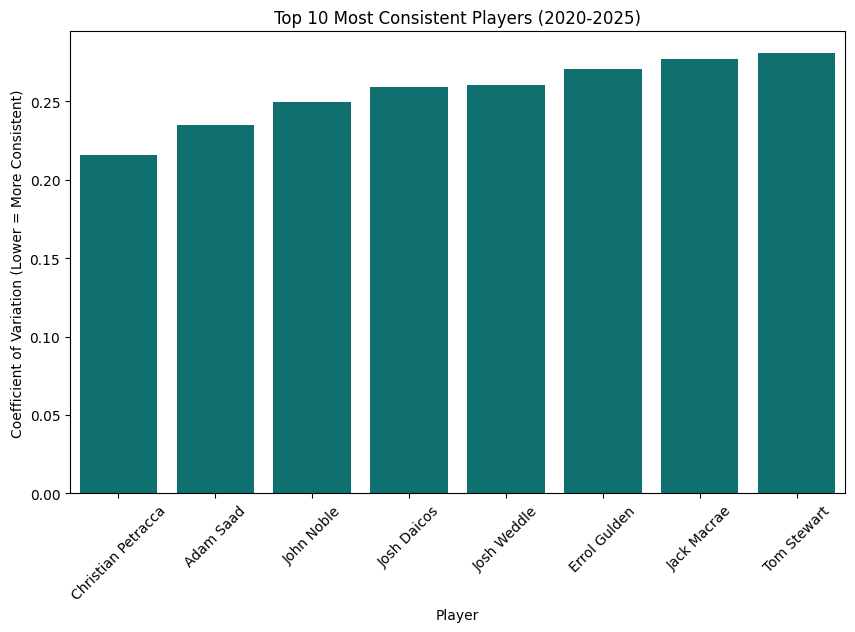

In [28]:
# Top 10 Most Consistent Players
plt.figure(figsize=(10, 6))
sns.barplot(data=consistent_players,x='player_name',y='CV',color='teal')
plt.title('Top 10 Most Consistent Players (2020-2025)')
plt.xlabel('Player')
plt.ylabel('Coefficient of Variation (Lower = More Consistent)')
plt.xticks(rotation=45)
plt.show()

# **Performance Trends**

In [29]:
r_stat['round_num'] = pd.to_numeric(r_stat['round'], errors='coerce')

# First half
first_half = r_stat[r_stat['round_num'] <= 11]
first_half_avg = first_half.groupby('player_id')['fantasy_points'].mean().reset_index()

# Second half
second_half = r_stat[r_stat['round_num'] > 11]
second_half_avg = second_half.groupby('player_id')['fantasy_points'].mean().reset_index()

# Join both results
player_trend = pd.merge(first_half_avg, second_half_avg, on='player_id')
player_trend.columns = ['player_id', 'fantasy_points_H1', 'fantasy_points_H2']

# Performance change
player_trend['Performance_Change'] = player_trend['fantasy_points_H2'] - player_trend['fantasy_points_H1']

# Add player names
player_trend = pd.merge(player_trend, players[['player_id', 'player_name']], on='player_id')

In [30]:
improved_players = player_trend.sort_values('Performance_Change', ascending=False).head(10)
print("TOP 10 MOST IMPROVED PLAYERS")
display(improved_players[['player_name', 'fantasy_points_H1', 'fantasy_points_H2', 'Performance_Change']].round(2))

declined_players = player_trend.sort_values('Performance_Change', ascending=True).head(10)
print("\nTOP 10 MOST DECLINED PLAYERS")
display(declined_players[['player_name', 'fantasy_points_H1', 'fantasy_points_H2', 'Performance_Change']].round(2))

TOP 10 MOST IMPROVED PLAYERS


,player_name,fantasy_points_H1,fantasy_points_H2,Performance_Change
40,Josh Schache,19.00,52.11,33.11
27,Tom Lynch,60.70,84.86,24.16
29,Shaun Mannagh,66.80,88.78,21.98
24,Adam Kennedy,34.43,54.27,19.84
13,Matt Eagles,7.00,26.00,19.00
47,James Tunstill,18.50,36.67,18.17
38,Trey Ruscoe,32.33,47.89,15.56
51,Marcus Windhager,58.00,73.42,15.42
2,Sam Berry,56.25,69.46,13.21
21,Oliver Hollands,59.40,72.22,12.82



TOP 10 MOST DECLINED PLAYERS


,player_name,fantasy_points_H1,fantasy_points_H2,Performance_Change
3,Jye Caldwell,112.00,67.00,-45.00
12,Lynden Dunn,54.00,25.00,-29.00
19,Liam Henry,65.00,40.00,-25.00
50,Justin Westhoff,71.40,48.00,-23.40
28,Jack Macrae,102.52,91.75,-10.77
44,Zach Sproule,49.60,41.12,-8.48
35,Mitch Owens,68.19,60.00,-8.19
18,Brayden Ham,40.64,32.64,-7.99
23,Neville Jetta,32.17,25.00,-7.17
32,Oisin Mullin,49.70,42.72,-6.98


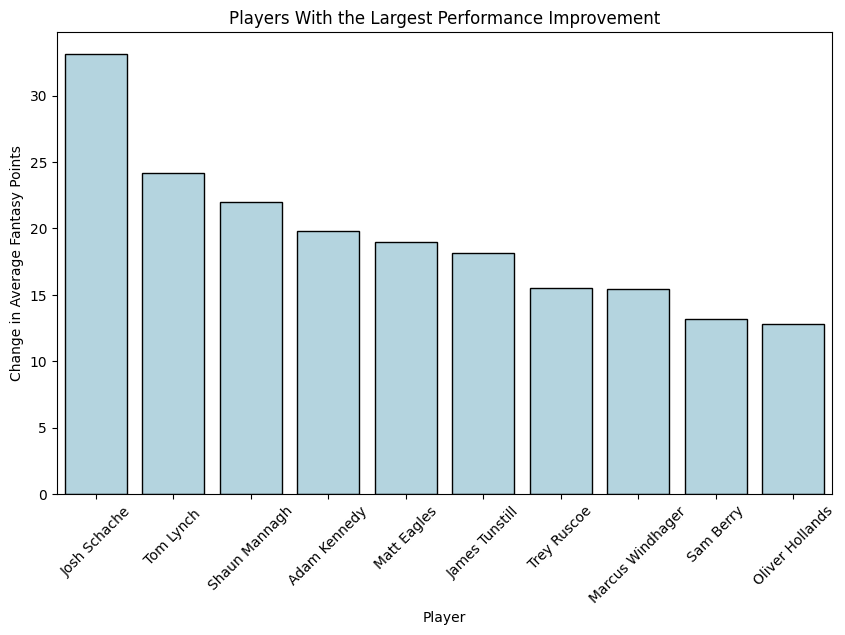

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(data=improved_players,x="player_name",y="Performance_Change",color="lightblue",edgecolor="black")

plt.title("Players With the Largest Performance Improvement")
plt.xlabel("Player")
plt.ylabel("Change in Average Fantasy Points")
plt.xticks(rotation=45)
plt.show()

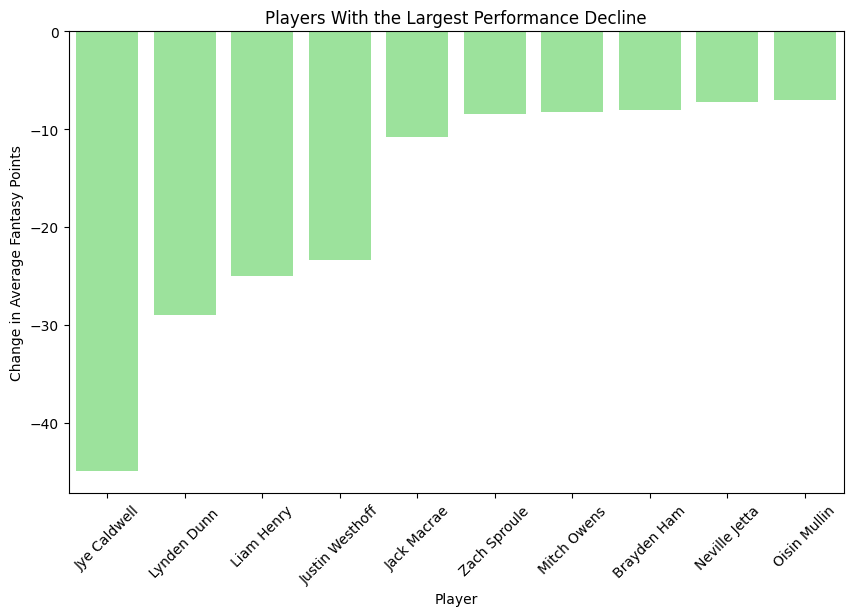

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(data=declined_players,x="player_name",y="Performance_Change",color="lightgreen")

plt.title("Players With the Largest Performance Decline")
plt.xlabel("Player")
plt.ylabel("Change in Average Fantasy Points")
plt.xticks(rotation=45)
plt.show()

# **Team Rankings**

In [33]:
# Filter 2020 to 2025 AND Exclude Finals
df_filtered = merged_players[(merged_players["year"] >= 2020)& (merged_players["year"] <= 2025)
                                                             & (merged_players["is_finals"] == False)].copy()

# Clean Team Names
df_filtered["team"] = df_filtered["team"].astype(str).str.strip().str.title()

# Perform Groupby & Ranking
team_performance = (
    df_filtered.groupby("team")
    .agg(
        Player_Games=("player_id", "count"),
        Average_Fantasy=("total_fantasy_points", "mean"),
        Average_Disposals=("disposals", "mean"),
        Average_Clearances=("clearances", "mean"),
        Average_Goals=("goals", "mean"),
        Average_Tackles=("tackles", "mean"),
    )
    .reset_index()
)

In [34]:
# Rank teams by average Fantasy Points
team_performance["Team_Rank"] = (team_performance["Average_Fantasy"].rank(ascending=False, method="min").astype(int))
team_performance = team_performance.sort_values("Team_Rank")

print("Team Performance Ranking, 2020 TO 2025 (EXCLUDING FINALS)")
display(team_performance[[
            "Team_Rank",
            "team",
            "Player_Games",
            "Average_Fantasy",
            "Average_Disposals",
            "Average_Clearances",
            "Average_Goals",
            "Average_Tackles",
        ]].round(2))

Team Performance Ranking, 2020 TO 2025 (EXCLUDING FINALS)


,Team_Rank,team,Player_Games,Average_Fantasy,Average_Disposals,Average_Clearances,Average_Goals,Average_Tackles
15,1,Sydney Swans,153,1015.19,237.61,25.27,7.95,41.57
12,2,Port Adelaide Power,154,968.93,231.99,25.98,6.95,39.99
14,3,St Kilda Saints,160,966.67,234.50,21.08,6.74,37.76
10,4,Melbourne Demons,166,954.64,227.99,22.28,7.30,34.30
6,5,Geelong Cats,142,954.11,217.68,19.55,10.26,33.94
5,6,Fremantle Dockers,151,943.34,231.58,23.79,7.44,36.77
9,7,Hawthorn Hawks,171,926.85,223.88,21.92,7.29,36.87
1,8,Brisbane Lions,158,926.37,211.18,25.71,7.92,34.11
4,9,Essendon Bombers,147,915.88,215.41,19.83,7.24,32.71
3,10,Collingwood Magpies,159,901.58,212.28,19.83,5.81,36.48


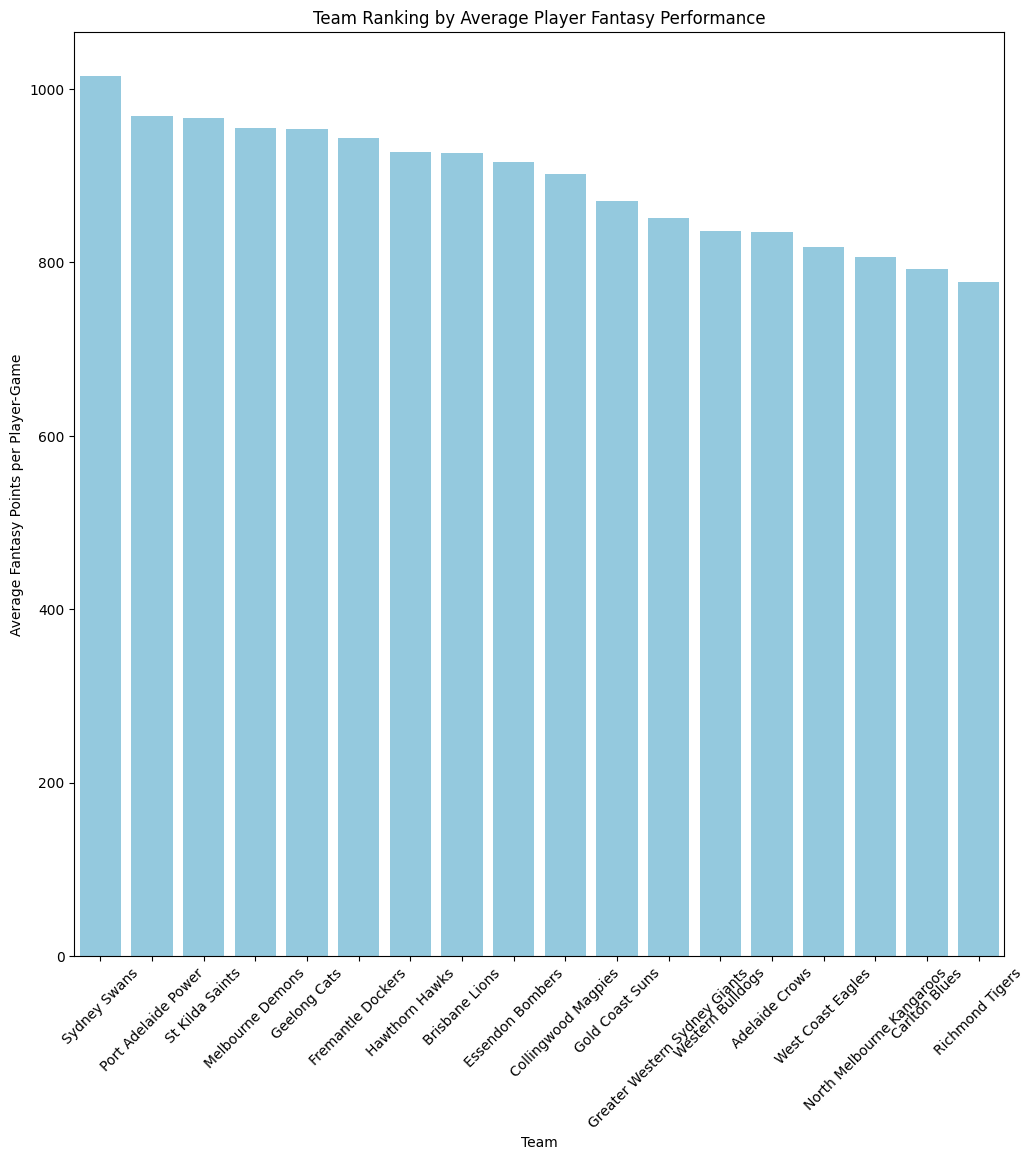

In [35]:
plt.figure(figsize=(12, 12))

sns.barplot(data=team_performance,x="team",y="Average_Fantasy",color="skyblue")

plt.title("Team Ranking by Average Player Fantasy Performance")
plt.xlabel("Team")
plt.ylabel("Average Fantasy Points per Player-Game")
plt.xticks(rotation=45)
plt.show()

# **Final Recruitment Recommendations**

In [37]:
# Calculate player stats (games, average, standard deviation)
player_stats = r_stat.groupby('player_id')['fantasy_points'].agg(
    Games='count',
    Avg_Points='mean',
    Std_Dev='std'
).reset_index()

# Calculate consistency (Coefficient of Variation)
player_stats['CV'] = player_stats['Std_Dev'] / player_stats['Avg_Points']

# 3. Merge player trends and names
merged_data = player_stats.merge(player_trend[['player_id', 'Performance_Change']], on='player_id', how='left')
merged_data = merged_data.merge(players[['player_id', 'player_name']], on='player_id', how='left')

# Filter players with at least 30 games
final_players = merged_data[merged_data['Games'] >= 30].copy()

# 5. Calculate final recruitment score
final_players['Recruitment_Score'] = (
    final_players['Avg_Points']
    - (final_players['CV'] * 10)
    + (final_players['Performance_Change'] * 0.5)
)

In [38]:
# Select top 5 players
top_5_players = final_players.sort_values(by='Recruitment_Score', ascending=False).head(5)

# Display results
print("--- TOP 5 RECOMMENDED PLAYERS ---")
display(top_5_players[['player_name', 'Games', 'Avg_Points', 'CV', 'Performance_Change', 'Recruitment_Score']].round(2))

--- TOP 5 RECOMMENDED PLAYERS ---


,player_name,Games,Avg_Points,CV,Performance_Change,Recruitment_Score
95,Christian Petracca,78,99.73,0.22,2.28,98.72
40,Errol Gulden,71,99.49,0.27,3.19,98.38
119,Tom Stewart,77,92.13,0.28,5.33,91.99
68,Jack Macrae,81,95.60,0.28,-10.77,87.45
20,Josh Daicos,79,85.57,0.26,5.24,85.59


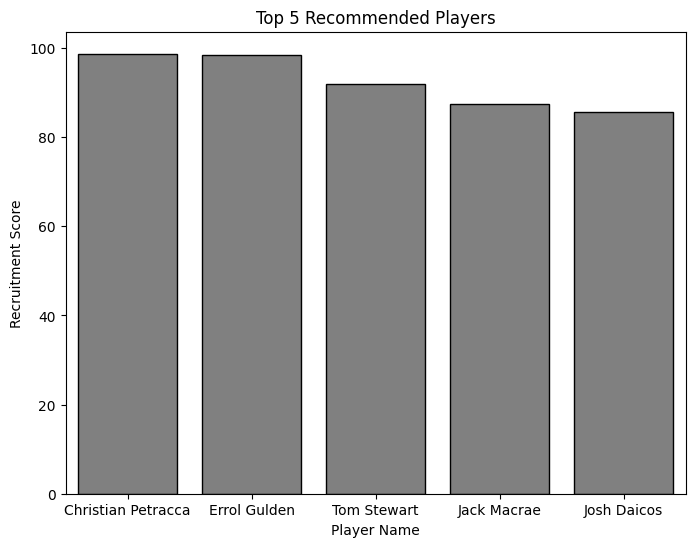

In [43]:
plt.figure(figsize=(8, 6))

sns.barplot(data=top_5_players, x='player_name', y='Recruitment_Score', color='grey', edgecolor='black')
plt.title('Top 5 Recommended Players')
plt.xlabel('Player Name')
plt.ylabel('Recruitment Score')
plt.show()

# **Correlation HeatMap**

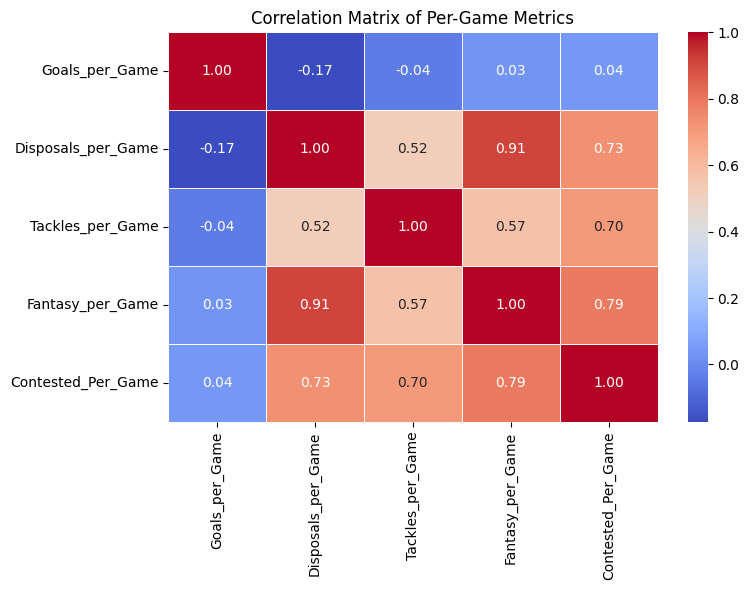

In [44]:
plt.figure(figsize=(8, 6))
cols = [
    'Goals_per_Game',
    'Disposals_per_Game',
    'Tackles_per_Game',
    'Fantasy_per_Game',
    'Contested_Per_Game',
]
corr = players[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Per-Game Metrics')
plt.tight_layout()
plt.show()

# **Histogram with KDE True**

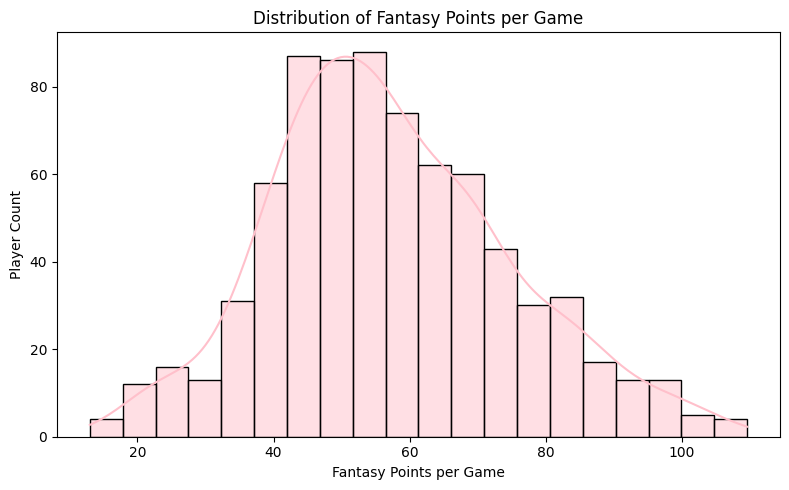

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(players['Fantasy_per_Game'], kde=True, color='pink', bins=20)

plt.title('Distribution of Fantasy Points per Game')
plt.xlabel('Fantasy Points per Game')
plt.ylabel('Player Count')
plt.tight_layout()
plt.show()

# **Final Summary**

In [46]:
# Final Recommendation Summary
final_recommendations = top_5_players.merge(
    players[[
        'player_id',
        'Fantasy_per_Game',
        'Goals_per_Game',
        'Disposals_per_Game',
        'Tackles_per_Game',
        'Clearances_per_Game',
        'Contested_Per_Game'
    ]],on='player_id',how='left')

In [ ]:
# Select final columns
final_recommendations = final_recommendations[[
    'player_name',
    'Games',
    'Fantasy_per_Game',
    'Goals_per_Game',
    'Disposals_per_Game',
    'Tackles_per_Game',
    'Clearances_per_Game',
    'Contested_Per_Game',
    'CV',
    'Performance_Change',
    'Recruitment_Score'
]].copy()

# Add ranking
final_recommendations.insert(0, 'Rank', range(1, 6))

# Round values to 2 decimal points
final_recommendations = final_recommendations.round(2)
final_recommendations